# Step 1 — Data Structure Exploration

## Project Overview

The goal is to train a **CNN regressor** that predicts 4 morphological parameters from 5-band galaxy images (g/r/i/z/y):

| Parameter | Physical Meaning |
|-----------|-----------------|
| `i_ellipticity` | Ellipticity (0 = circular, 1 = maximally elongated) |
| `i_major_axis` | Semi-major axis (arcsec) |
| `i_sersic_index` | Sérsic index (n=1: exponential disk, n=4: de Vaucouleurs profile) |
| `i_isophotal_area` | Isophotal area (pixels²) |

Training data: **GalaxiesML** dataset from the HSC survey — 286,401 galaxies in HDF5 format.  
Evaluation target: 10,000 synthetic galaxy images produced by our **DDPM generative model**.

This notebook covers **Step 1**: understanding the data layout before any cleaning or training.

## 1.1 Imports and Paths

In [1]:
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR   = "/Users/wen/Desktop/project/archive"
GEN_DIR    = "/Users/wen/Desktop/project/lizarraga_2024-main/generated_images"

HDF5_FILES = {
    "train" : os.path.join(DATA_DIR, "5x64x64_training_with_morphology.hdf5"),
    "val"   : os.path.join(DATA_DIR, "5x64x64_validation_with_morphology.hdf5"),
    "test"  : os.path.join(DATA_DIR, "5x64x64_testing_with_morphology.hdf5"),
}

TARGET_COLS = ["i_ellipticity", "i_major_axis", "i_sersic_index", "i_isophotal_area"]
BANDS       = ["g", "r", "i", "z", "y"]

## 1.2 HDF5 File Sizes and Sample Counts

The dataset is split into train / val / test. We check the file sizes on disk and confirm how many galaxies are in each split.

In [2]:
print(f"{'Split':<8} {'File size':>12}  {'N samples':>10}  Image shape")
print("-" * 55)
for split, path in HDF5_FILES.items():
    size_gb = os.path.getsize(path) / 1e9
    with h5py.File(path, "r") as f:
        shape = f["image"].shape
    print(f"{split:<8} {size_gb:>10.1f} GB  {shape[0]:>10,}  {shape[1:]}")

Split       File size   N samples  Image shape
-------------------------------------------------------
train          16.9 GB     204,573  (5, 64, 64)
val             3.4 GB      40,914  (5, 64, 64)
test            3.4 GB      40,914  (5, 64, 64)


## 1.3 All Available Keys in the HDF5

Each HDF5 stores morphological measurements for all 5 HSC bands (g, r, i, z, y) plus image data and catalogue metadata. We print every dataset name and its shape.

In [3]:
# Inspect the training file — all splits share the same schema
with h5py.File(HDF5_FILES["train"], "r") as f:
    print(f"{'Key':<45} {'Shape':>20}  {'dtype'}")
    print("-" * 80)
    def _print(name, obj):
        if hasattr(obj, "shape"):
            print(f"  {name:<43} {str(obj.shape):>20}  {obj.dtype}")
    f.visititems(_print)

Key                                                          Shape  dtype
--------------------------------------------------------------------------------
  coord                                                  (204573,)  |S60
  dec                                                    (204573,)  float64
  g_central_image_pop_10px_rad                           (204573,)  int64
  g_central_image_pop_15px_rad                           (204573,)  int64
  g_central_image_pop_5px_rad                            (204573,)  int64
  g_cmodel_mag                                           (204573,)  float64
  g_cmodel_magsigma                                      (204573,)  float64
  g_ellipticity                                          (204573,)  float64
  g_half_light_radius                                    (204573,)  float64
  g_isophotal_area                                       (204573,)  float64
  g_major_axis                                           (204573,)  float64
  g_minor_axis    

## 1.4 Target Column Statistics

We focus on the 4 i-band morphological parameters that the CNN will learn to predict.  
We check mean, std, min, max, and NaN count across all three splits to confirm data quality and consistency.

In [4]:
for split, path in HDF5_FILES.items():
    print(f"\n{'='*60}")
    print(f"  Split: {split}")
    print(f"{'='*60}")
    print(f"  {'Column':<22} {'mean':>8} {'std':>8} {'min':>8} {'max':>8} {'NaN':>6}")
    print(f"  {'-'*62}")
    with h5py.File(path, "r") as f:
        for col in TARGET_COLS:
            arr = f[col][:]
            nans = int(np.sum(np.isnan(arr)))
            print(f"  {col:<22} {np.nanmean(arr):>8.3f} {np.nanstd(arr):>8.3f} "
                  f"{np.nanmin(arr):>8.3f} {np.nanmax(arr):>8.3f} {nans:>6}")


  Split: train
  Column                     mean      std      min      max    NaN
  --------------------------------------------------------------
  i_ellipticity             0.242    0.171    0.000    0.936      0
  i_major_axis              6.078    3.901    0.000   37.983      0
  i_sersic_index            1.902    1.104    0.000    9.997      0
  i_isophotal_area        956.122 1012.181    0.000 7729.000      0

  Split: val
  Column                     mean      std      min      max    NaN
  --------------------------------------------------------------
  i_ellipticity             0.243    0.171    0.000    0.885      0
  i_major_axis              6.103    3.903    0.629   33.234      0
  i_sersic_index            1.913    1.113    0.300   10.000      0
  i_isophotal_area        963.363 1018.648    5.000 7046.000      0

  Split: test
  Column                     mean      std      min      max    NaN
  --------------------------------------------------------------
  i_elliptic

## 1.5 Visualise Sample Galaxy Images

We display a random galaxy from the training set across all 5 HSC bands to get an intuition for the data.  
The image tensor is stored as `(N, 5, 64, 64)` — band order is g, r, i, z, y.

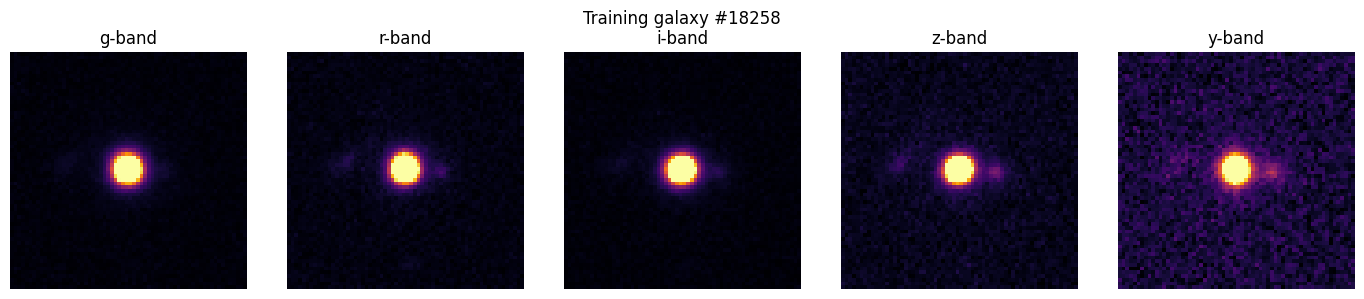


Morphological labels for this galaxy:
  i_ellipticity          = 0.2450
  i_major_axis           = 3.1580
  i_sersic_index         = 1.2310
  i_isophotal_area       = 378.0000


In [5]:
rng = np.random.default_rng(42)
idx = rng.integers(0, 204573)

with h5py.File(HDF5_FILES["train"], "r") as f:
    img   = f["image"][idx]          # (5, 64, 64)
    label = {col: float(f[col][idx]) for col in TARGET_COLS}

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle(f"Training galaxy #{idx}", fontsize=12)

for ax, band, channel in zip(axes, BANDS, img):
    # clip low / high percentile for display
    vmin, vmax = np.percentile(channel, [1, 99])
    ax.imshow(channel, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"{band}-band")
    ax.axis("off")

plt.tight_layout()
plt.savefig("figures/sample_galaxy_bands.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nMorphological labels for this galaxy:")
for k, v in label.items():
    print(f"  {k:<22} = {v:.4f}")

## 1.6 Generated Images Directory

The DDPM model has produced 10,000 synthetic galaxy images saved as PyTorch `.pt` tensors, plus a `generated_redshifts.npy` file with the corresponding redshift for each image.  
We confirm file counts, tensor shapes, and value ranges.

In [6]:
all_files = os.listdir(GEN_DIR)
pt_files  = sorted(f for f in all_files if f.endswith(".pt"))
npy_files = sorted(f for f in all_files if f.endswith(".npy"))

print(f"Total files in generated_images/: {len(all_files)}")
print(f"  .pt  tensors : {len(pt_files)}")
print(f"  .npy arrays  : {npy_files}")

# Inspect one tensor
sample_pt = torch.load(os.path.join(GEN_DIR, pt_files[0]), map_location="cpu", weights_only=True)
print(f"\nSample tensor — shape: {sample_pt.shape}, dtype: {sample_pt.dtype}")
print(f"  pixel range: [{sample_pt.min():.4f}, {sample_pt.max():.4f}]")

# Inspect redshifts
redshifts = np.load(os.path.join(GEN_DIR, "generated_redshifts.npy"))
print(f"\nRedshift array — shape: {redshifts.shape}, dtype: {redshifts.dtype}")
print(f"  range: [{redshifts.min():.4f}, {redshifts.max():.4f}]")
print(f"  mean ± std: {redshifts.mean():.4f} ± {redshifts.std():.4f}")

Total files in generated_images/: 10001
  .pt  tensors : 10000
  .npy arrays  : ['generated_redshifts.npy']

Sample tensor — shape: torch.Size([5, 64, 64]), dtype: torch.float32
  pixel range: [-1.1511, 48.5888]

Redshift array — shape: (10000,), dtype: float64
  range: [0.0130, 3.9842]
  mean ± std: 0.5974 ± 0.5774


## 1.7 Visualise a Generated Galaxy

Side-by-side comparison of one generated image (all 5 bands) vs one real training galaxy.

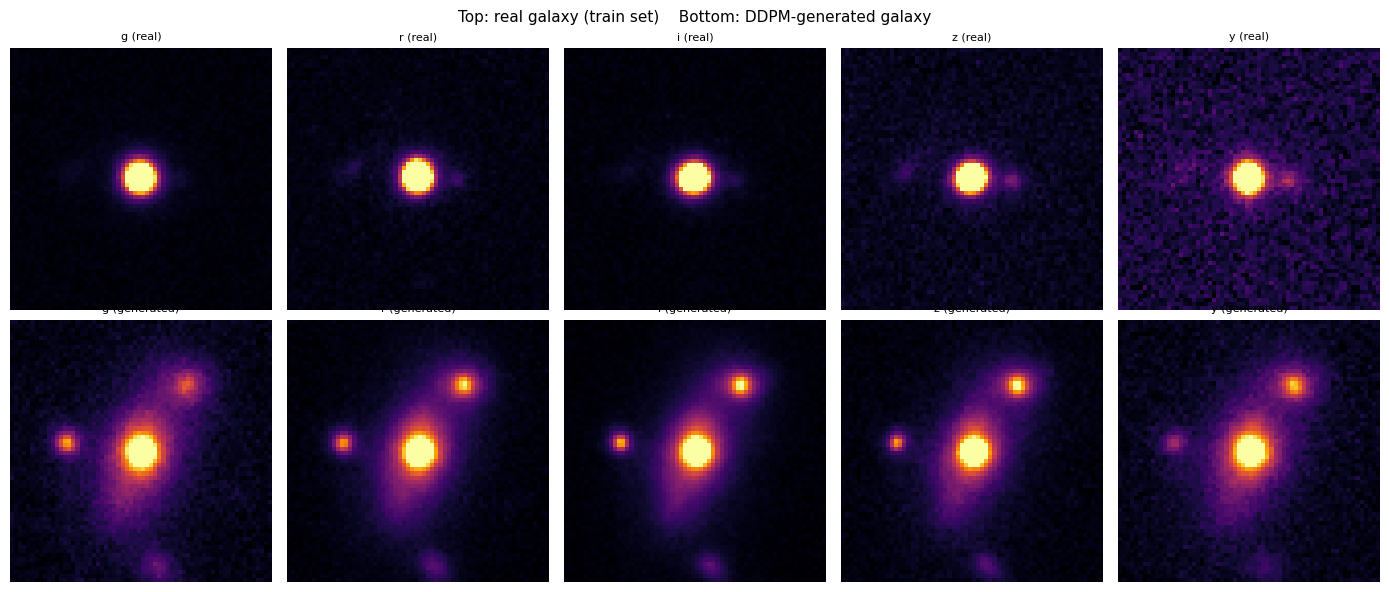

In [7]:
gen_img = torch.load(os.path.join(GEN_DIR, pt_files[0]), map_location="cpu", weights_only=True).numpy()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Top: real galaxy (train set)    Bottom: DDPM-generated galaxy", fontsize=11)

for col, (band, real_ch, gen_ch) in enumerate(zip(BANDS, img, gen_img)):
    for row, (ax, ch, title) in enumerate(zip(
        axes[:, col],
        [real_ch, gen_ch],
        ["real", "generated"]
    )):
        vmin, vmax = np.percentile(ch, [1, 99])
        ax.imshow(ch, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
        ax.set_title(f"{band} ({title})", fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.savefig("figures/real_vs_generated.png", dpi=100, bbox_inches="tight")
plt.show()

## 1.8 Summary

| Item | Finding |
|------|---------|
| Train / Val / Test split | 204,573 / 40,914 / 40,914 galaxies |
| Image shape | `(N, 5, 64, 64)` float32 — 5 HSC bands, 64×64 px |
| Target columns | 4 i-band parameters, **zero NaN** across all splits |
| Suspicious zeros | `i_major_axis`, `i_isophotal_area`, `i_ellipticity` have min = 0 → need filtering in Step 2 |
| Sersic index cap | max ≈ 10.0 in training set → some values are at the measurement upper limit |
| Generated images | 10,000 × `(5, 64, 64)` float32 `.pt` files + 10,000 redshifts `.npy` |
| Format compatibility | Same 5-band 64×64 layout  — pixel scale needs checking in Step 2 |

**Next:** Step 2 — data cleaning, outlier removal, normalisation, and building the DataLoader.